C:\Users\ASUS\AppData\Local\Temp\ipykernel_10008\1863166182.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10008\1863166182.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


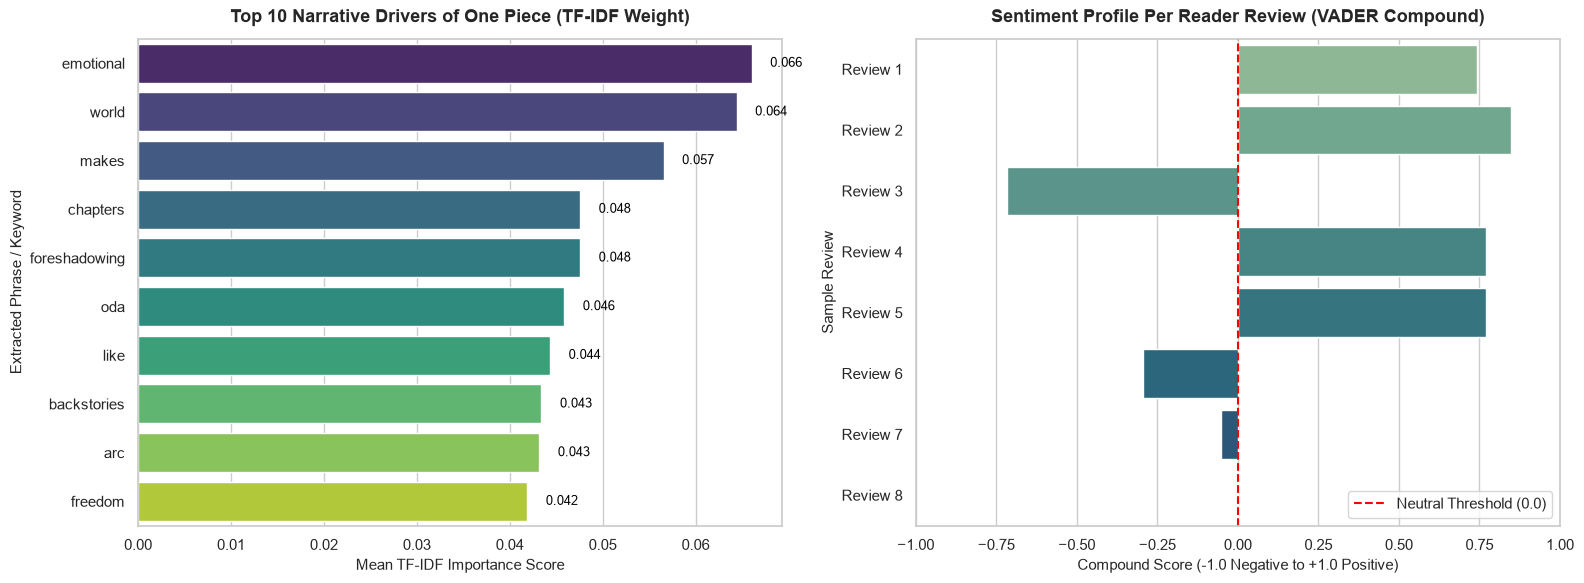

In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# ------------------------------------------------------------------
# 1. Setup & Corpus Preparation
# ------------------------------------------------------------------
# Download required NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)

# Extended corpus representing reader discussions and critical reviews
reviews_data = [
    "One Piece has the greatest world building in fiction. Oda's foreshadowing across hundreds of chapters creates unparalleled narrative depth.",
    "The emotional core is unmatched. The concept of freedom, found family, nakama, and inherited will makes every arc deeply emotional and inspiring.",
    "Eiichiro Oda creates incredible characters with heartbreaking backstories. The themes of political corruption, racism, and liberation elevate it above standard shonen.",
    "Its longevity and consistency are mind blowing. Every arc connects back to the grand lore, making re-reading extremely rewarding.",
    "Luffy's quest for freedom rather than mere power makes him a unique protagonist. The Straw Hats feel like a real family.",
    "Masterpiece of storytelling! The emotional tragedy in backstories like Robin, Law, and Sanji makes you weep.",
    "The interconnectivity of the world, from the World Government to ancient weapons and Void Century, keeps fans engaged for decades.",
    "Foreshadowing introduced 500 chapters ago finally pays off. Oda is a master planner."
]

# ------------------------------------------------------------------
# 2. Text Preprocessing & Cleaning
# ------------------------------------------------------------------
def preprocess_text(text):
    # Remove punctuation, numbers, and lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    # Remove standard English stop words
    stop_words = set(stopwords.words('english'))
    words = text.split()
    return " ".join([w for w in words if w not in stop_words])

cleaned_corpus = [preprocess_text(doc) for doc in reviews_data]

# ------------------------------------------------------------------
# 3. TF-IDF Analysis (Extract Narrative Drivers)
# ------------------------------------------------------------------
vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words='english')
tfidf_matrix = vectorizer.fit_transform(cleaned_corpus)
feature_names = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(tfidf_matrix.todense(), columns=feature_names)
top_keywords = df_tfidf.mean(axis=0).sort_values(ascending=False).head(10)

# ------------------------------------------------------------------
# 4. Sentiment Analysis (VADER)
# ------------------------------------------------------------------
sid = SentimentIntensityAnalyzer()
sentiment_scores = []

for idx, review in enumerate(reviews_data, 1):
    scores = sid.polarity_scores(review)
    sentiment_scores.append({
        'Review_ID': f'Review {idx}',
        'Compound': scores['compound'],
        'Positive': scores['pos'],
        'Negative': scores['neg']
    })

df_sentiment = pd.DataFrame(sentiment_scores)

# ------------------------------------------------------------------
# 5. Data Visualization
# ------------------------------------------------------------------
# Set visual style
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Top Narrative Key Drivers (TF-IDF)
sns.barplot(
    x=top_keywords.values, 
    y=top_keywords.index, 
    palette='viridis', 
    ax=ax1
)
ax1.set_title('Top 10 Narrative Drivers of One Piece (TF-IDF Weight)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Mean TF-IDF Importance Score', fontsize=11)
ax1.set_ylabel('Extracted Phrase / Keyword', fontsize=11)

# Annotate values on bars
for p in ax1.patches:
    ax1.annotate(
        f'{p.get_width():.3f}', 
        (p.get_width() + 0.002, p.get_y() + p.get_height() / 2.),
        ha='left', va='center', fontsize=9, color='black'
    )

# Plot B: VADER Sentiment Scores Across Reviews
sns.barplot(
    x='Compound', 
    y='Review_ID', 
    data=df_sentiment, 
    palette='crest', 
    ax=ax2
)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Neutral Threshold (0.0)')
ax2.set_title('Sentiment Profile Per Reader Review (VADER Compound)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Compound Score (-1.0 Negative to +1.0 Positive)', fontsize=11)
ax2.set_ylabel('Sample Review', fontsize=11)
ax2.set_xlim(-1.0, 1.0)
ax2.legend(loc='lower right')

# Layout adjustment & Display
plt.tight_layout()
plt.savefig('one_piece_text_analysis.png', dpi=300)
plt.show()